# Purpose:
- Clustering based on multi-session coding scores.
- Going to be added to glm_analysis_tools

In [2]:
import sys
sys.path.append('/root/capsule/code/')

from DesignMatrix import DesignMatrix
import glm_fit_tools as gft
import design_matrix_tools as dmtools
import kernel_tools as ktools
import load_data
import vba_tools

from sklearn.cluster import SpectralClustering

import os
import glob
from pathlib import Path
import numpy as np
import pandas as pd
import xarray as xr
import json

from matplotlib import pyplot as plt
import seaborn as sns

# notebook dev
%load_ext autoreload
%autoreload 2
%matplotlib inline
import capsule_utils



# Load data
- cross-session normalization
- roicat df

In [9]:
# GLM parameters
dm_version = 1
data_type = 'events'
suffix = '00'

# Loading session information
data_dir = '/root/capsule/data'
data_folders = [d for d in glob.glob(data_dir + '/*') if Path(d).is_dir()]
raw_paths = np.sort([d for d in data_folders if ('processed' not in d.split('/')[-1]) and
                 ('dlc-eye' not in d.split('/')[-1]) and
                 ('multiplane-ophys' in d.split('/')[-1]) and 
                 ('stimuli' not in d.split('/')[-1]) and
                 ('stim-response' not in d.split('/')[-1]) and
                 ('ROICat' not in d.split('/')[-1])])
glm_dir = '/root/capsule/scratch/Thyme'

session_names = [rp.split('/')[-1] for rp in raw_paths]
session_keys = ['_'.join(sn.split('_')[1:3]) for sn in session_names]
session_inds = np.arange(len(session_names))
session_types = []
for raw_path in raw_paths:
    session_json_fn = Path(raw_path) / 'session.json'
    with open(session_json_fn) as f:
        session_json = json.load(f)
    session_types.append(session_json['session_type'])
session_info_df = pd.DataFrame({'session_name': session_names,
                                'session_key': session_keys,
                                'session_ind': session_inds,
                                'session_type': session_types}) 
session_info_df.set_index('session_key', drop=True, inplace=True)
session_info_df

,session_name,session_ind,session_type
session_key,,,
736963_2024-07-24,multiplane-ophys_736963_2024-07-24_08-49-57,0,TRAINING_3_images_A_10uL_reward
736963_2024-07-26,multiplane-ophys_736963_2024-07-26_09-37-45,1,TRAINING_3_images_A_10uL_reward
736963_2024-07-29,multiplane-ophys_736963_2024-07-29_09-00-58,2,TRAINING_4_images_A_training
736963_2024-07-30,multiplane-ophys_736963_2024-07-30_09-11-03,3,TRAINING_5_images_A_epilogue
736963_2024-08-01,multiplane-ophys_736963_2024-08-01_08-59-00,4,TRAINING_5_images_A_handoff_ready
736963_2024-08-05,multiplane-ophys_736963_2024-08-05_09-19-25,5,OPHYS_1_images_A
736963_2024-08-06,multiplane-ophys_736963_2024-08-06_08-52-03,6,OPHYS_1_images_A
736963_2024-08-07,multiplane-ophys_736963_2024-08-07_09-11-10,7,OPHYS_4_images_B
736963_2024-08-09,multiplane-ophys_736963_2024-08-09_08-58-36,8,OPHYS_4_images_B


In [4]:
session_ind_name_dict = {6: 'Familiar',
                         7: 'Novel',
                         8: 'Novel+1'}

In [5]:
roicat_df_fn = '/root/capsule/scratch/Thyme/roicat_df.pkl'
roicat_df = pd.read_pickle(roicat_df_fn)
f1n2_session_inds = [6, 7, 8]
f1n2_roi_df = roicat_df.query('valid_roi and (session_ind in @f1n2_session_inds) and matched')
f1n2_uc_series = f1n2_roi_df.groupby('unique_cell_name').size()
f1n2_matched_uc = f1n2_uc_series.index.values[np.where(f1n2_uc_series==len(f1n2_session_inds))[0]]
print(len(f1n2_matched_uc))
f1n2_all_matched_roi_df = f1n2_roi_df.query('unique_cell_name in @f1n2_matched_uc')
f1n2_all_matched_roi_df.head()

291


,roi_index,fov_name,session_name,roi_session_index,ucid,roi_id,silhouette,hdbscan_probability,matched,session_key_x,session_ind,unique_cell_name,cell_roi_id,valid_roi,exclusion_labels,touching_motion_border,small_roi,session_key_y,plane_session_key,session_key
roi_name,,,,,,,,,,,,,,,,,,,,
736963_2024-08-09_VISp_0_0005,5,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,5,88,db55ec77-70e9-4e64-8e7f-caa9660a4d5e,0.992339,0.976572,True,736963_2024-08-09,8,VISp_0_0088,5,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0007,7,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,7,101,f2aabcb6-bfb4-40ee-9ea1-e7f420475ab5,0.902556,1.000000,True,736963_2024-08-09,8,VISp_0_0101,7,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0008,8,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,8,98,fb45dc23-e4d5-4ebf-a5a9-b0c3c4eb36ff,0.982731,1.000000,True,736963_2024-08-09,8,VISp_0_0098,8,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0009,9,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,9,99,8483a820-9d1f-4576-ae40-7b868e611d9e,0.917262,1.000000,True,736963_2024-08-09,8,VISp_0_0099,9,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09
736963_2024-08-09_VISp_0_0010,10,VISp_0,multiplane-ophys_736963_2024-08-09_08-58-36_pr...,10,3,127fcf28-5de9-480a-8218-3a5850abeaf5,0.985113,0.968638,True,736963_2024-08-09,8,VISp_0_0003,10,True,None,False,False,736963_2024-08-09,736963_2024-08-09_VISp_0,736963_2024-08-09


In [6]:
f1n2_all_matched_roi_df.valid_roi.all()

True

## Load feature table

In [7]:
feature_table_fn = '/root/capsule/scratch/Thyme/clustering/feature_table_fnn.pkl'
feature_table = pd.read_pickle(feature_table_fn)

## Generate and save feature table

In [359]:
dm_version = 1
data_type = 'events'
suffix = '00'

include_models = ['all-images', 'omissions', 'behavioral', 'task']

coding_score_table = f1n2_all_matched_roi_df.reset_index()[['roi_name', 'unique_cell_name', 'session_ind', 'session_key', 'fov_name', 'roi_session_index']].copy()

session_keys = np.sort(coding_score_table.session_key.unique())

coding_score_raw = None
for session_key in session_keys:
    session_matched_roi_name = ['_'.join(rn.split('_')[-3:]) for rn in f1n2_all_matched_roi_df.query(f'session_key=="{session_key}"').index.values]
    
    session_name = session_info_df.loc[session_key, 'session_name']
    session_ind = session_info_df.loc[session_key, 'session_ind']
    coding_score_fn = Path(glm_dir) / f'coding_score_736963_natural_images_v01_events/coding_score_v{dm_version:02}_{session_name}_{data_type}_{suffix}.nc'
    with xr.open_dataarray(coding_score_fn) as ds:
        coding_score_session = ds.expand_dims('session').assign_coords(session=[session_ind_name_dict[session_ind]])
        cell_roi_ids = coding_score_session.cell_roi_id.values
        
        # get filtered cell_roi_ids during glm fitting (<1% active frames)
        X, response, response_info, run_params, unstd_features, use_indices = \
            gft.load_data(session_name, data_type, dm_version, load_path=glm_dir)
        response_trim = response[use_indices, :]
        response_trim_filtered = gft.filter_response_matrix(response_trim)
        filtered_cell_roi_id = np.setdiff1d(response_trim.cell_roi_id.values, response_trim_filtered.cell_roi_id.values)
        
        # if there are missing cell_roi_ids among filtered cell_roi_ids, add them to coding_score_session and fill with 0
        missing_cell_roi_ids = np.setdiff1d(filtered_cell_roi_id, cell_roi_ids)
        if len(missing_cell_roi_ids) > 0:
            new_cell_roi_ids = np.concatenate([cell_roi_ids, missing_cell_roi_ids])
            coding_score_session = coding_score_session.reindex(cell_roi_id=new_cell_roi_ids, fill_value=0)
        
        # Choose only the matched cell_roi_ids
        # Also only from models of interest
        coding_score_session = coding_score_session.sel(cell_roi_id=session_matched_roi_name, model=include_models).copy()
        
        # Swap cell_roi_id which is session-specific to unique_cell_name for concatenation across sessions
        unique_cell_names = []
        for cell_roi_id in coding_score_session.cell_roi_id.values:
            roi_name = f'{session_key}_{cell_roi_id}'
            unique_cell_names.append(f1n2_all_matched_roi_df.loc[roi_name, 'unique_cell_name'])

        coding_score_session = coding_score_session.assign_coords(unique_cell_name=("cell_roi_id", unique_cell_names))
        coding_score_session = coding_score_session.swap_dims({"cell_roi_id": "unique_cell_name"})
        coding_score_session = coding_score_session.reset_coords('cell_roi_id', drop=True)
    if coding_score_raw is None:
        coding_score_raw = coding_score_session
    else:
        coding_score_raw = xr.concat([coding_score_raw, coding_score_session], dim='session')
        
max_full_score = coding_score_raw.max(dim='session')
assert len(np.where(coding_score_raw.isnull())[0]) == 0

In [360]:
# Normalized coding score
coding_score_normalized = \
    -((coding_score_raw.sel(metric='adj_ve_full') - coding_score_raw.sel(metric='adj_ve_model')) / coding_score_raw.sel(metric='adj_ve_full').max(dim='session'))    
    
# filtering
filter_threshold = 0.005
mask_from_max = max_full_score.sel(metric='adj_ve_full') < filter_threshold
sessions = coding_score_raw.session.values
mask_from_max = xr.concat([mask_from_max] * len(sessions), dim="session")
mask_from_max = mask_from_max.assign_coords(session=sessions)
mask_from_raw = coding_score_raw.sel(metric='adj_ve_model') < filter_threshold

coding_score_normalized_filtered = coding_score_normalized.where(~(mask_from_max + mask_from_raw), other=0)

# clipping
coding_score_normalized_filtered_clipped = coding_score_normalized_filtered.clip(min=-1, max=0)
assert len(np.where(coding_score_normalized_filtered_clipped.isnull())[0]) == 0

### NaN issue
- It's not from nonactive neurons
- It was because of using session cell_roi_id instead of unique_cell_name
- Also there were filtered rois that need to be included with 0 ve and coding scores
- Lastly, cells should have been filtered based on matching from roicat_df

In [361]:
coding_score_novelty = coding_score_normalized_filtered_clipped.sel(model=include_models)
coding_score_novelty_df = coding_score_novelty.to_dataframe().reset_index()

In [362]:
coding_score_novelty_df.head()

,session,model,unique_cell_name,metric,coding_score_metrics_from_session_model
0,Familiar,all-images,VISp_0_0003,adj_ve_full,-0.344747
1,Familiar,all-images,VISp_0_0007,adj_ve_full,-0.359956
2,Familiar,all-images,VISp_0_0009,adj_ve_full,-0.026662
3,Familiar,all-images,VISp_0_0010,adj_ve_full,-0.041693
4,Familiar,all-images,VISp_0_0024,adj_ve_full,-0.099998


In [363]:
coding_score_table['experience_level'] = coding_score_table.session_ind.map(session_ind_name_dict)
coding_score_table.head()

,roi_name,unique_cell_name,session_ind,session_key,fov_name,roi_session_index,experience_level
0,736963_2024-08-09_VISp_0_0005,VISp_0_0088,8,736963_2024-08-09,VISp_0,5,Novel+1
1,736963_2024-08-09_VISp_0_0007,VISp_0_0101,8,736963_2024-08-09,VISp_0,7,Novel+1
2,736963_2024-08-09_VISp_0_0008,VISp_0_0098,8,736963_2024-08-09,VISp_0,8,Novel+1
3,736963_2024-08-09_VISp_0_0009,VISp_0_0099,8,736963_2024-08-09,VISp_0,9,Novel+1
4,736963_2024-08-09_VISp_0_0010,VISp_0_0003,8,736963_2024-08-09,VISp_0,10,Novel+1


In [364]:
set(coding_score_table.unique_cell_name.unique()) == set(coding_score_novelty_df.unique_cell_name.unique())

True

In [366]:
for model in include_models:
    coding_score_table[model] = coding_score_table.apply(lambda x: coding_score_novelty_df.query(f'model=="{model}" and session=="{x.experience_level}" and unique_cell_name=="{x.unique_cell_name}"').coding_score_metrics_from_session_model.values[0], axis=1)
assert len(np.where(coding_score_table[include_models].isnull().values)[0]) == 0

In [367]:
feature_table = coding_score_table.pivot(index='unique_cell_name', columns='experience_level', values=include_models)
feature_table

all-images                     omissions                      \
experience_level   Familiar     Novel   Novel+1  Familiar     Novel   Novel+1   
unique_cell_name                                                                
VISp_0_0003       -0.344747 -0.649337 -0.207473 -0.158431 -0.170559 -0.100082   
VISp_0_0007       -0.359956 -0.517923 -0.179919 -0.160380 -0.217843 -0.071751   
VISp_0_0009       -0.026662 -0.182029 -0.118804 -0.021136 -0.214475 -0.066966   
VISp_0_0010       -0.041693 -0.257704 -0.070872 -0.033179 -0.078626 -0.022345   
VISp_0_0024       -0.099998 -0.445338 -0.158677 -0.083615 -0.122419 -0.105403   
...                     ...       ...       ...       ...       ...       ...   
VISp_7_0116       -0.427819 -0.747832 -0.250240 -0.145164 -0.175650 -0.106996   
VISp_7_0117       -0.106758 -0.182733 -0.123360 -0.039335 -0.120648 -0.018188   
VISp_7_0121       -0.209482 -0.076433 -0.144413 -0.129054 -0.147659 -0.257079   
VISp_7_0125       -0.593410 -0.631813 -0.568626 -0.008790 -0.107466 -0.023212   
VISp_7_0140       -0.282205 -0.547005 -0.201348 -0.130218 -0.116209 -0.140139   

                 behavioral                          task                      
experience_level   Familiar     Novel   Novel+1  Familiar     Novel   Novel+1  
unique_cell_name                                                               
VISp_0_0003       -0.183244 -0.069958 -0.121686 -0.124552 -0.302570 -0.342822  
VISp_0_0007       -0.125937 -0.166223 -0.217030 -0.107635 -0.251969 -0.067224  
VISp_0_0009       -0.522054 -0.541085 -0.407234 -0.050890 -0.249145 -0.139695  
VISp_0_0010       -0.403348 -0.692994 -0.466804 -0.047008 -0.079882 -0.056819  
VISp_0_0024       -0.055144 -0.094871 -0.094745 -0.125273 -0.332563 -0.183665  
...                     ...       ...       ...       ...       ...       ...  
VISp_7_0116       -0.146487 -0.107505 -0.423821 -0.253307 -0.077972 -0.145508  
VISp_7_0117       -0.406203 -0.607766 -0.798850 -0.117824 -0.307916 -0.090000  
VISp_7_0121       -0.356446 -0.421545 -0.667927 -0.210891 -0.180048 -0.282013  
VISp_7_0125       -0.126522 -0.070934 -0.232593 -0.331095 -0.282045 -0.178505  
VISp_7_0140       -0.312605 -0.253570 -0.215039 -0.178330 -0.265747 -0.351418  

[291 rows x 12 columns]

In [368]:
feature_table_with_info = feature_table.copy()
feature_table_with_info['plane_ind'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[1]))

In [369]:
feature_table_fn = '/root/capsule/scratch/Thyme/clustering/feature_table_fnn.pkl'
feature_table.to_pickle(feature_table_fn)

In [249]:
feature_table.columns.levels[0]

Index(['all-images', 'omissions', 'behavioral', 'task'], dtype='object')

# Low dimensional embedding
- PCA
- UMAP

Text(0, 0.5, 'cumulative explained variance')

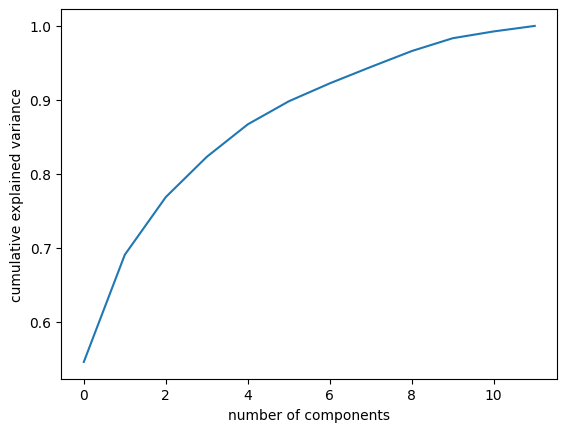

In [379]:
# PCA
from sklearn.decomposition import PCA
pca = PCA()
pca.fit(feature_table.values)
# show the results
fig, ax = plt.subplots()
ax.plot(np.cumsum(pca.explained_variance_ratio_))
ax.set_xlabel('number of components')
ax.set_ylabel('cumulative explained variance')

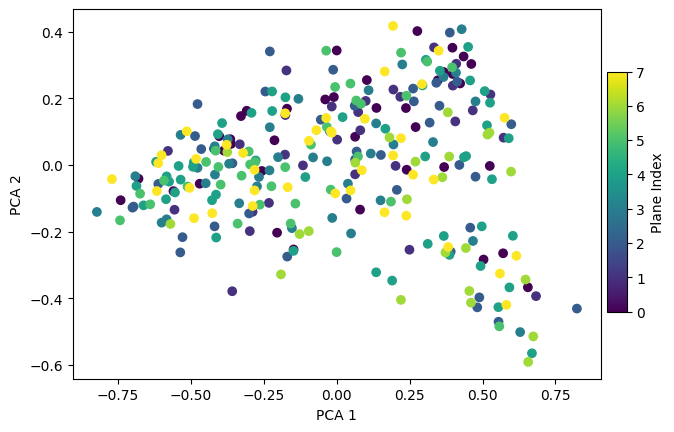

In [380]:
# show embedding
feature_table_with_info = feature_table.copy()
feature_table_with_info['plane_ind'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[1]))

fig, ax = plt.subplots()
feature_table_pca = pca.transform(feature_table.values)
ax.scatter(feature_table_pca[:, 0], feature_table_pca[:, 1], c=feature_table_with_info['plane_ind'], cmap='viridis')
ax.set_xlabel('PCA 1')
ax.set_ylabel('PCA 2')

fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.25, 0.03, 0.5])
cbar = fig.colorbar(ax.collections[0], cax=cbar_ax)
cbar.set_label('Plane Index')


In [381]:
# Show in interactive 3D using plotly
import plotly.graph_objs as go
fig = go.Figure(data=[go.Scatter3d(x=feature_table_pca[:, 0],
                                   y=feature_table_pca[:, 1],
                                   z=feature_table_pca[:, 2],
                                   mode='markers',
                                   marker=dict(size=4,
                                               color=feature_table_with_info['plane_ind'],
                                               colorscale='viridis',
                                               opacity=1))])

# Set plot layout
fig.update_layout(scene=dict(
    xaxis_title="PC 1",
    yaxis_title="PC 2",
    zaxis_title="PC 3"
))

fig.update_layout(
    height=800  # Set the height
)

fig.show()


In [308]:
feature_table_with_info = feature_table.copy()
feature_table_with_info['plane_ind'] = feature_table_with_info.index.map(lambda x: int(x.split('_')[1]))

Task exception was never retrieved
future: <Task finished name='Task-52370' coro=<Client._gather.<locals>.wait() done, defined at /opt/conda/lib/python3.9/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-52371' coro=<Client._gather.<locals>.wait() done, defined at /opt/conda/lib/python3.9/site-packages/distributed/client.py:2396> exception=AllExit()>
Traceback (most recent call last):
  File "/opt/conda/lib/python3.9/site-packages/distributed/client.py", line 2405, in wait
    raise AllExit()
distributed.client.AllExit
Task exception was never retrieved
future: <Task finished name='Task-52372' coro=<Client._gather.<locals>.wait() done, defined at /opt/conda/lib/python3.9/site-packages/distributed/client.py:2396> exception=AllExit()>
Tr

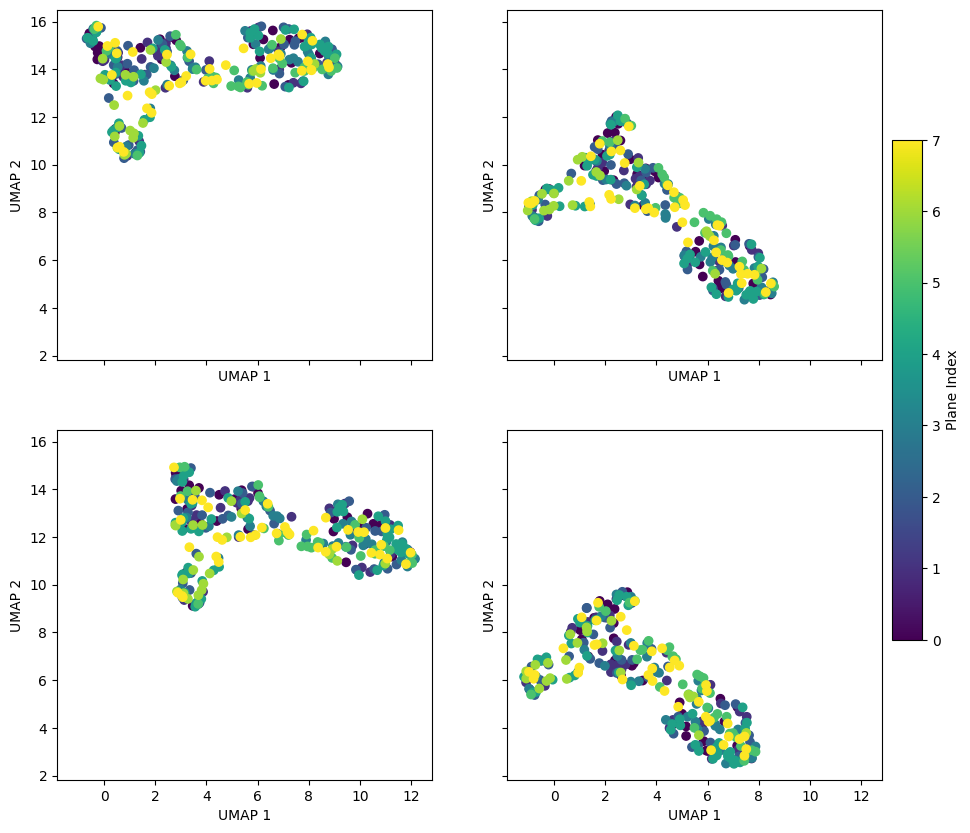

In [382]:
# show feature_table data in UMAP
import umap
fig, ax = plt.subplots(2,2, sharex=True, sharey=True, figsize=(10,10))
for i in range(4):
    ix, iy = i//2, i%2
    
    reducer = umap.UMAP()
    embedding = reducer.fit_transform(feature_table.values)
    
    ax[iy, ix].scatter(embedding[:, 0], embedding[:, 1], c=feature_table_with_info['plane_ind'].values)
    ax[iy, ix].set_xlabel('UMAP 1')
    ax[iy, ix].set_ylabel('UMAP 2')
# add a colorbar by adding a space to the right of the figure
fig.subplots_adjust(right=0.95)
cbar_ax = fig.add_axes([0.96, 0.25, 0.03, 0.5])
cbar = fig.colorbar(ax[0,0].collections[0], cax=cbar_ax)
cbar.set_label('Plane Index')


# Hierarchical clustering

In [383]:
# hierarchical clustering
from sklearn.cluster import AgglomerativeClustering
hc = AgglomerativeClustering()
gap_df_hc = vba_tools.compute_gap(clustering=hc, data=feature_table, k_max = k_max, 
                                reference_shuffle=shuffle_type, metric=metric)

Reference inertia for 1 clusters
Reference inertia for 2 clusters
Reference inertia for 3 clusters
Reference inertia for 4 clusters
Reference inertia for 5 clusters
Reference inertia for 6 clusters
Reference inertia for 7 clusters
Reference inertia for 8 clusters
Reference inertia for 9 clusters
Reference inertia for 10 clusters
Reference inertia for 11 clusters
Reference inertia for 12 clusters
Reference inertia for 13 clusters
Reference inertia for 14 clusters
Reference inertia for 15 clusters
Reference inertia for 16 clusters
Reference inertia for 17 clusters
Reference inertia for 18 clusters
Reference inertia for 19 clusters
Reference inertia for 20 clusters
Reference inertia for 21 clusters
Reference inertia for 22 clusters
Reference inertia for 23 clusters
Reference inertia for 24 clusters
Reference inertia for 25 clusters
Reference inertia for 26 clusters
Reference inertia for 27 clusters
Reference inertia for 28 clusters
Reference inertia for 29 clusters
Reference inertia for 3

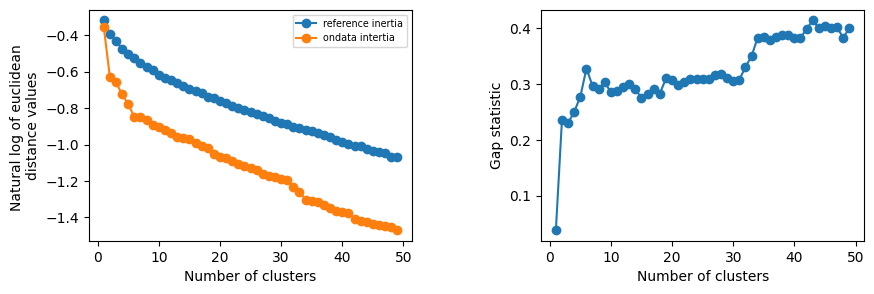

In [384]:
vba_tools.plot_gap_statistic(gap_df_hc)

In [350]:
hc.fit(feature_table.values)

AgglomerativeClustering(n_clusters=49)

Text(0.5, -43.777777777777686, '')

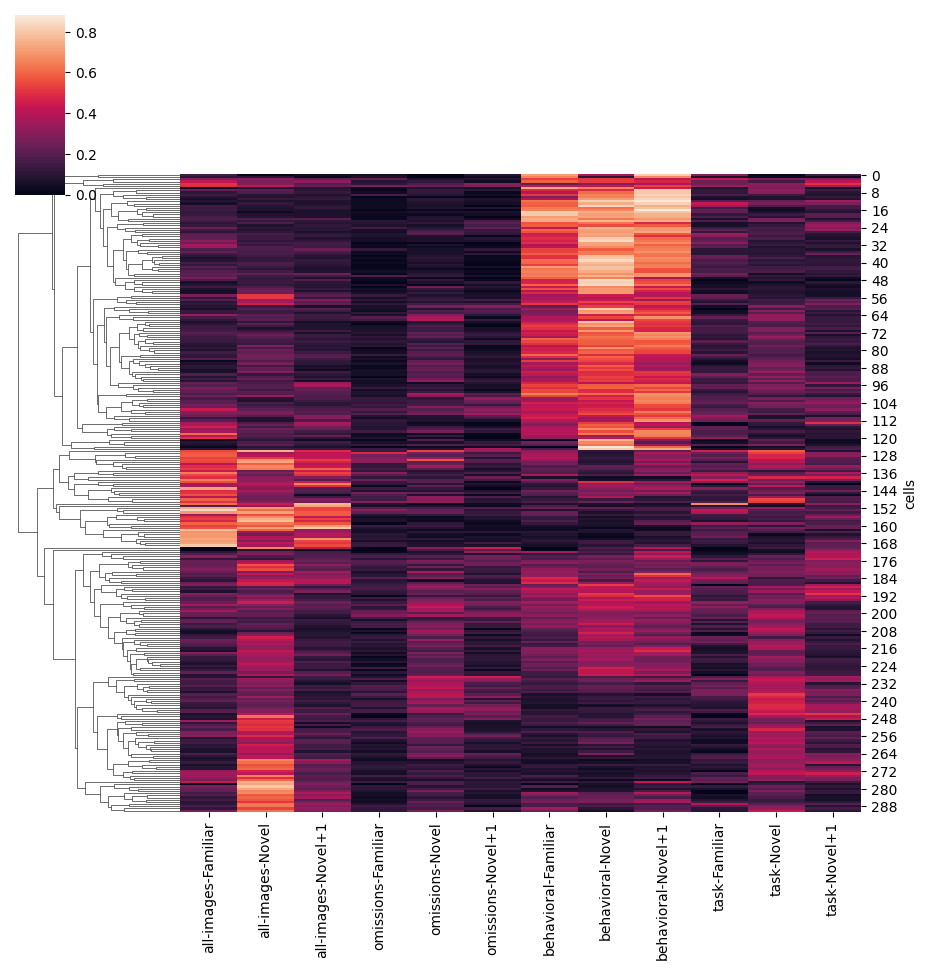

In [389]:

g = sns.clustermap(-feature_table, row_cluster=True, col_cluster=False,)
ax = g.ax_heatmap
ytick_positions = g.ax_heatmap.get_yticks()
ax.set_yticklabels([int(y) for y in ytick_positions]);
ax.set_ylabel('cells')
ax.set_xlabel('')

# Spectral clustering

In [15]:
# Spectral clustering parameters
metric = 'euclidean' # default distance metric
shuffle_type ='all' # default shuffle type is all shuffle (cell id and regressors)
k_max = 50 #max number of clusters to test


In [ ]:
# Gap statistics
sc = SpectralClustering()
gap_df = vba_tools.compute_gap(clustering=sc, data=feature_table, k_max = k_max, 
                                reference_shuffle=shuffle_type, metric=metric, parallel=False)
gap_df.keys()

In [10]:
# Load gap statistics
gap_save_fn = Path(glm_dir) / f'clustering/gap_{dm_version:02}_{data_type}_{suffix}.npy'
gap_df = np.load(gap_save_fn, allow_pickle=True).item()

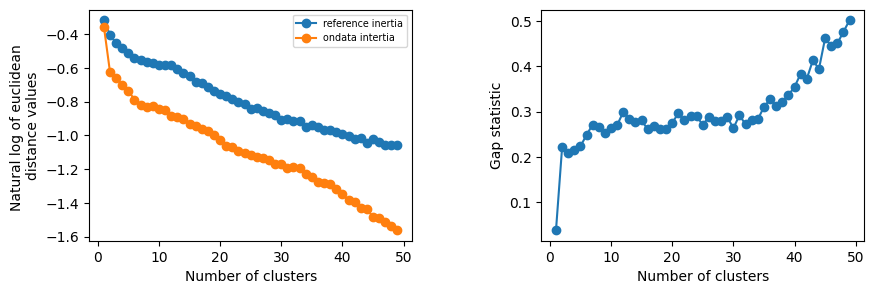

In [11]:
vba_tools.plot_gap_statistic(gap_df)

In [ ]:
# saving gap_df
gap_save_fn = Path(glm_dir) / f'clustering/gap_{dm_version:02}_{data_type}_{suffix}.npy'
gap_save_fn.parent.mkdir(parents=True, exist_ok=True)
np.save(gap_save_fn, gap_df)

In [17]:
sc = SpectralClustering()
sc.fit(feature_table.values)
A = sc.affinity_matrix_
eigenvalues, eigenvectors, nb_clusters = vba_tools.get_eigenDecomposition(A, max_n_clusters=k_max)

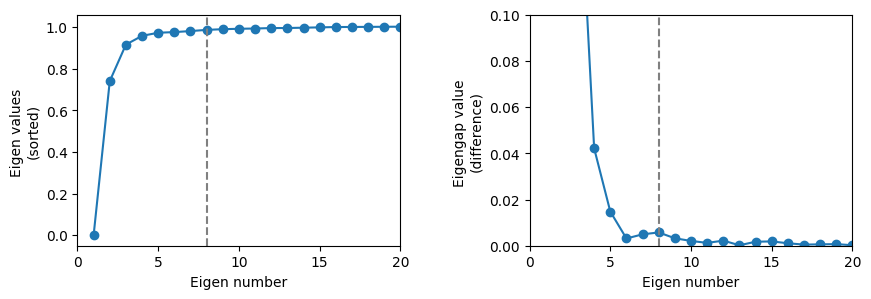

In [22]:
vba_tools.plot_eigengap_values(eigenvalues, n_clusters=8)

In [25]:
# Silhouette Score
n_clusters = np.arange(3,26)
n_boots = 20
silhouette_scores, silhouette_std = vba_tools.get_silhouette_scores(
    X=feature_table.values, model=SpectralClustering(), n_clusters=n_clusters, metric=metric, n_boots=n_boots)

size of X = (291, 12)
NaNs in the array = 0
n 3 clusters mean score = 0.2996917771479139
n 4 clusters mean score = 0.22236160710652722
n 5 clusters mean score = 0.19650645383975845
n 6 clusters mean score = 0.13315671536255083
n 7 clusters mean score = 0.14191646131225705
n 8 clusters mean score = 0.1298775459619707
n 9 clusters mean score = 0.12522253975995493
n 10 clusters mean score = 0.12390241522616582
n 11 clusters mean score = 0.11157052615386134
n 12 clusters mean score = 0.09990537293578908
n 13 clusters mean score = 0.10094117066446409
n 14 clusters mean score = 0.09423820798205332
n 15 clusters mean score = 0.09077182342808934
n 16 clusters mean score = 0.08890961559119162
n 17 clusters mean score = 0.09341402408298324
n 18 clusters mean score = 0.08407346264513141
n 19 clusters mean score = 0.08365828036992158
n 20 clusters mean score = 0.07808725809132847
n 21 clusters mean score = 0.08589242921569967
n 22 clusters mean score = 0.08286402953260412
n 23 clusters mean score 

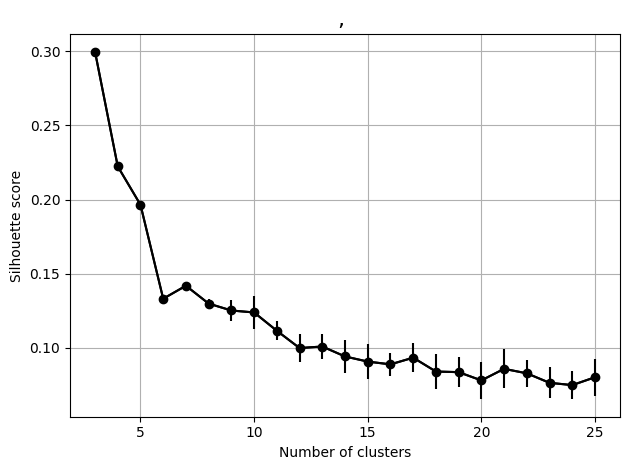

In [29]:
fig, ax = plt.subplots()
vba_tools.plot_silhouette_scores(silhouette_scores=silhouette_scores, silhouette_std=silhouette_std, 
                                 n_clusters=n_clusters, ax=ax);

In [31]:
# Co-clustering
n_clusters = 8
sc = SpectralClustering()
X = feature_table.values
m = vba_tools.get_coClust_matrix(X=X, n_clusters=n_clusters, model=sc, nboot=np.arange(150))
coclustering_df = pd.DataFrame(data=m, index=feature_table.index, columns=feature_table.index)

  0%|          | 0/150 [00:00<?, ?it/s]

100%|██████████| 150/150 [00:22<00:00,  6.67it/s]


In [ ]:
cluster_meta = vba_tools.create_and_save_cluster_meta(coclustering_df, n_clusters, feature_table, cells_table_matched, cluster_meta_filename)

## Coclustering seems weird
- It makes sense only when the clustering method is highly variable
- It makes more sense to randomly sample data points to look at co-clustering.
- Ignore this for now

## Other metrics
- Dunn index
- Davies-Bouldin index
- Calinski-Harabasz index (variance ratio criterion)


## Brute-force
- Test multiple number of clusters
- Look at their mean responses

In [37]:
n_boots = 10
repeat_labels = []
for _ in range(n_boots):
    model = SpectralClustering(n_clusters=5)
    model.fit_predict(feature_table.values)
    repeat_labels.append(model.labels_)

In [93]:
def order_cluster_ind_by_size(label):
    cluster_inds = np.unique(label)
    # sort by size and re-index
    cluster_size = np.array([np.sum(label==ci) for ci in cluster_inds])
    sorted_inds = np.argsort(-cluster_size)

    new_label = np.zeros(len(label), dtype=int) - 1
    for i in range(len(cluster_inds)):
        new_label[label==cluster_inds[sorted_inds[i]]] = i
    assert len(np.where(new_label==-1)[0]) == 0
    return new_label

n_clusters = np.arange(5,11)
labels = []
for n_cluster in n_clusters:
    model = SpectralClustering(n_clusters=n_cluster)
    model.fit_predict(feature_table.values)    
    labels.append(order_cluster_ind_by_size(model.labels_))
    

Text(0.5, 1.0, 'Spectral clustering num clusters=10')

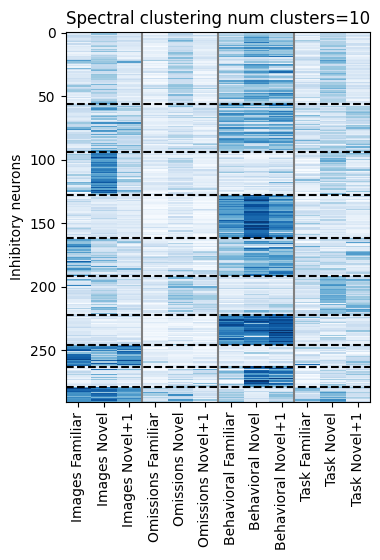

In [94]:
model_ind = 5
num_cluster = n_clusters[model_ind]
label = labels[model_ind]
fig, ax = plt.subplots()
index = feature_table.index.values
sorted_index = index[np.argsort(label)]


ax.imshow(-feature_table.loc[sorted_index, :].values, aspect=0.05, interpolation='none', cmap='Blues')

cluster_inds = np.unique(label)
cluster_size = np.array([np.sum(label==ci) for ci in cluster_inds])
cluster_borders = np.cumsum(cluster_size)

for cluster_border in cluster_borders[:-1]:
    ax.axhline(cluster_border, color='k', linestyle='--')
for x in [3,6,9]:
    ax.axvline(x-0.5, color='gray')

ax.set_xticks(range(12))
ax.set_xticklabels(['Images Familiar', 'Images Novel', 'Images Novel+1',
                'Omissions Familiar', 'Omissions Novel', 'Omissions Novel+1',
                'Behavioral Familiar', 'Behavioral Novel', 'Behavioral Novel+1',
                'Task Familiar', 'Task Novel', 'Task Novel+1'], rotation=90)
ax.set_ylabel('Inhibitory neurons')
ax.set_title(f'Spectral clustering num clusters={num_cluster}')

In [57]:
labels

[array([3, 1, 0, 0, 1, 4, 0, 2, 0, 1, 0, 0, 1, 1, 1, 1, 1, 3, 1, 1, 0, 1,
        0, 0, 0, 1, 1, 3, 2, 3, 0, 1, 0, 1, 1, 0, 1, 1, 1, 2, 1, 3, 2, 4,
        1, 1, 1, 1, 4, 0, 2, 1, 0, 2, 2, 1, 1, 3, 1, 1, 1, 0, 1, 0, 0, 3,
        0, 3, 4, 2, 3, 1, 0, 1, 2, 0, 2, 3, 1, 0, 1, 0, 1, 3, 0, 0, 1, 0,
        1, 0, 2, 3, 0, 1, 2, 1, 4, 4, 3, 4, 1, 3, 0, 3, 0, 0, 3, 2, 0, 0,
        0, 2, 3, 4, 1, 0, 1, 0, 0, 1, 3, 0, 2, 2, 0, 0, 0, 2, 1, 0, 2, 0,
        3, 2, 1, 3, 0, 2, 2, 0, 0, 1, 0, 1, 1, 1, 0, 1, 0, 0, 1, 1, 3, 0,
        0, 4, 2, 4, 2, 2, 0, 0, 1, 4, 3, 1, 3, 1, 0, 1, 0, 4, 0, 1, 3, 2,
        0, 1, 0, 0, 0, 4, 0, 3, 0, 1, 3, 0, 4, 0, 0, 1, 3, 0, 4, 1, 0, 2,
        0, 0, 0, 2, 2, 2, 2, 1, 0, 1, 1, 2, 2, 0, 2, 2, 2, 0, 2, 1, 2, 0,
        2, 0, 0, 1, 0, 2, 2, 2, 4, 0, 1, 3, 2, 2, 4, 3, 2, 3, 0, 2, 2, 0,
        0, 1, 2, 1, 1, 3, 2, 4, 1, 2, 0, 2, 2, 0, 0, 2, 1, 2, 2, 0, 2, 2,
        0, 3, 3, 2, 2, 2, 1, 2, 3, 2, 2, 2, 1, 0, 0, 3, 2, 1, 0, 0, 1, 0,
        3, 0, 2, 4, 3]),
 array([4, 0,

# Others (Archive)
- DBSCAN and OPTICS do not seem to be good

In [332]:
# dbscan clustering
from sklearn.cluster import DBSCAN
dbscan = DBSCAN()
gap_df_dbscan = vba_tools.compute_gap(clustering=dbscan, data=feature_table, k_max = k_max, 
                                reference_shuffle=shuffle_type, metric=metric)

shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling al

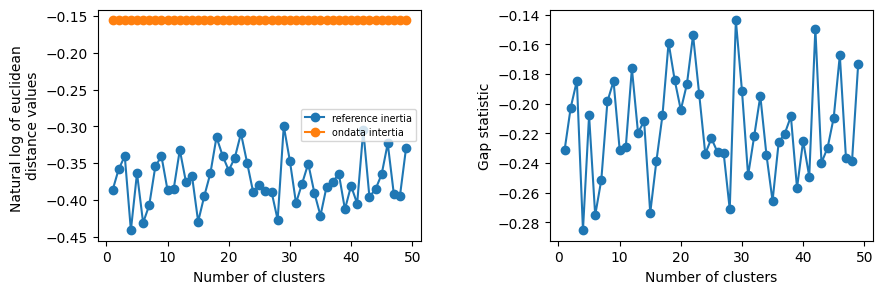

In [334]:
vba_tools.plot_gap_statistic(gap_df_dbscan)

In [333]:
# optics clustering
from sklearn.cluster import OPTICS
optics = OPTICS()
gap_df_optics = vba_tools.compute_gap(clustering=optics, data=feature_table, k_max = k_max, 
                                reference_shuffle=shuffle_type, metric=metric)

shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling all data
shuffling al

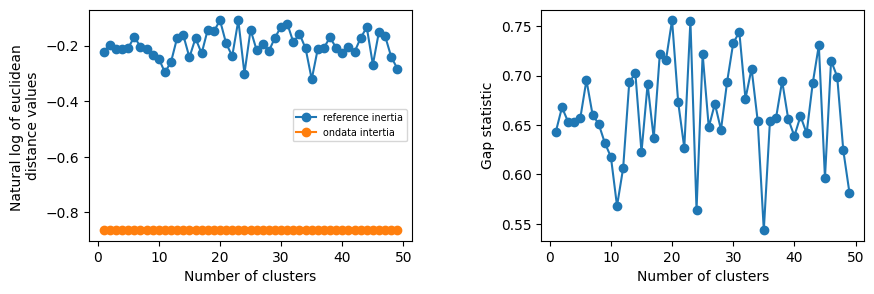

In [335]:
vba_tools.plot_gap_statistic(gap_df_optics)

In [348]:
optics = OPTICS(min_samples=3, xi=0.0001).fit(feature_table.values)

In [349]:
len(np.where(optics.labels_==-1)[0])

194

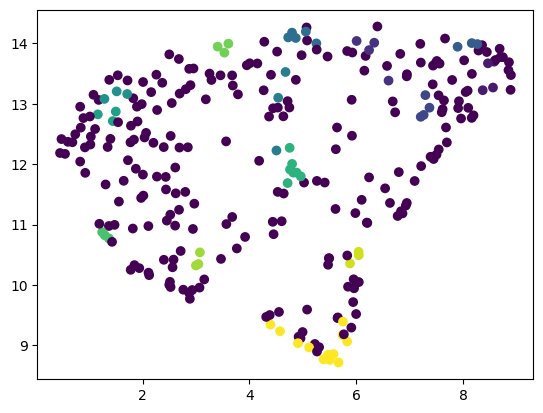

In [340]:
fig, ax = plt.subplots()
ax.scatter(embedding[:, 0], embedding[:, 1], c=optics.labels_, cmap='viridis')